https://github.com/aeon-toolkit/aeon/blob/main/examples/anomaly_detection/anomaly_detection.ipynb



https://www.sktime.net/en/v0.34.0/examples/07_detection_anomaly_changepoints.html

https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/anomalydetection.html

https://github.com/GeneSUN/Anomaly_Detection_toolkit

#### Импорт

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [7]:
from scipy import stats
# import pmdarima as pm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tsa.stattools import kpss
import statsmodels.api as sm

In [8]:
from pandas.tseries.frequencies import to_offset

In [9]:
from TSC_Nixtla_dump import *
plt_style_GOST()

In [10]:
from TSC_Nixtla_augmentation import *

In [11]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter("ignore", FutureWarning)

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

In [12]:
from functools import partial

### Загрузка данных

Импорт данных аналогично предыдущего урока.

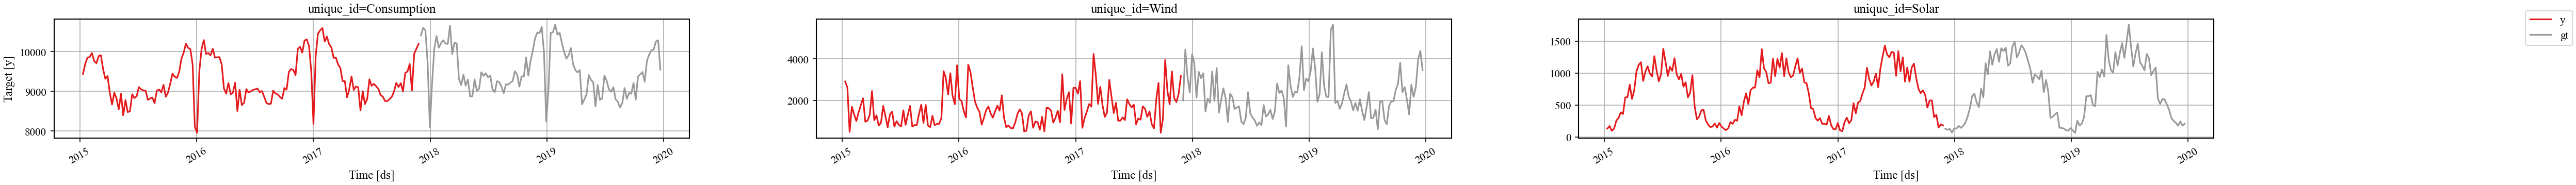

In [13]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']
y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series_v2(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1', n_cols = 3)

In [14]:
metric_map = {
    'mase': partial(mase, seasonality=SEASON),
    'mae': mae,
    'rmse': rmse,
    'smape': smape,
    'CPSR':scaled_crps,
    'CI':coverage,
    'SQL':partial(scaled_quantile_loss, seasonality=SEASON),
}
metrics = list(metric_map.values())
metric_names = list(metric_map.keys())

### Использование вероятностного предсказания для поиска аномалий

Here we identified the anomalies in the data using the MSTL model, but any probabilistic model from StatsForecast can be used. We also selected the 99% prediction interval of the insample forecasts, but other confidence levels can be used as well.

In [50]:
from statsforecast import StatsForecast
from statsforecast.models import MSTL, SeasonalNaive

#### выбор уровня доверия к данным 

In [51]:
levels = [99]

#### Выбор модели

In [52]:
models = [MSTL(season_length=[SEASON], alias='MSTL')]

#### Обучение модели  in-sample prediction

In [53]:
sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst = sf.forecast(df=df_train, h=FH, level=levels, fitted=True)

insample_forecasts = sf.forecast_fitted_values().drop(columns=['y'])

res_df = panel_df.merge(pd.concat([insample_forecasts,fcst],), on=['unique_id', 'ds'], how='left')


#### Выбор и визуализация номалий

In [56]:
anomalies = res_df[~res_df['y'].between(res_df['MSTL-lo-99'], res_df['MSTL-hi-99'])]
anomalies.head()

,unique_id,ds,y,MSTL,MSTL-lo-99,MSTL-hi-99
50,Consumption,2015-12-27,8106.565,8717.428300,8321.652892,9113.203708
102,Consumption,2016-12-25,9513.222,8891.184984,8495.409576,9286.960392
153,Consumption,2017-12-17,10535.852,9931.456661,9520.668407,10342.244915
154,Consumption,2017-12-24,9735.578,8830.469147,8413.014221,9247.924072
156,Consumption,2018-01-07,9216.217,9707.269506,9276.790859,10137.748153


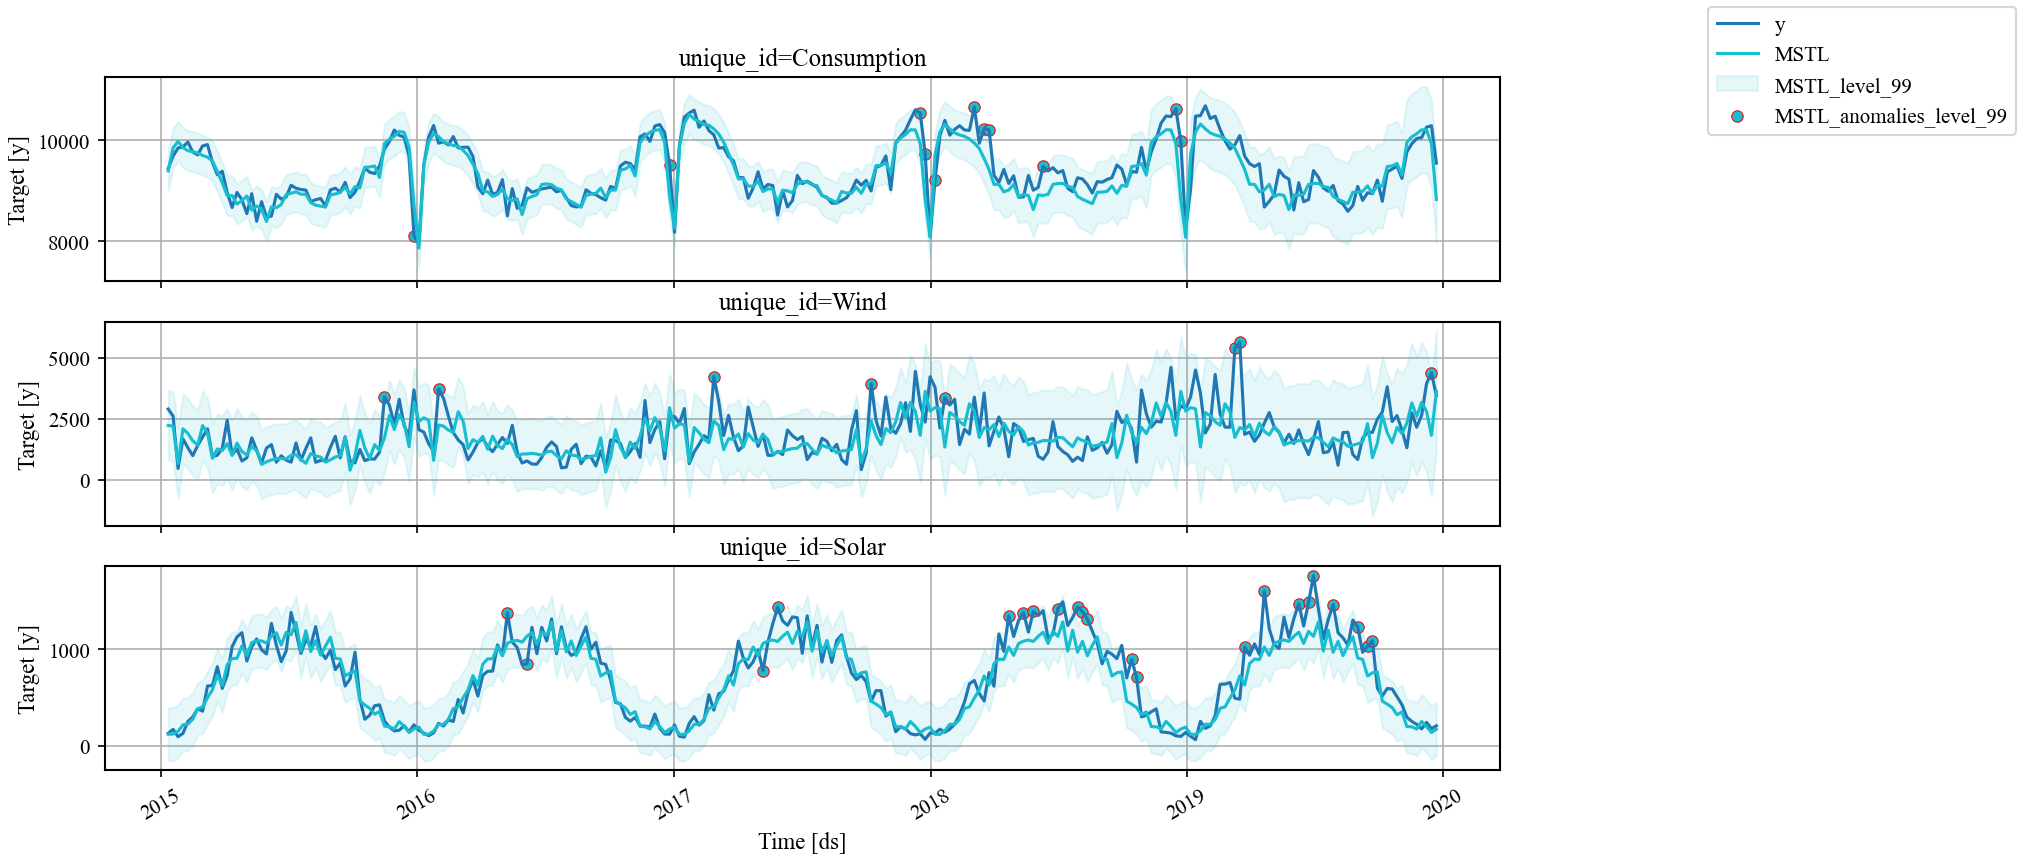

In [57]:
plot_series_v2(forecasts_df=res_df, level=levels, plot_anomalies=True)

NameError: name 'anomalies_filtered' is not defined

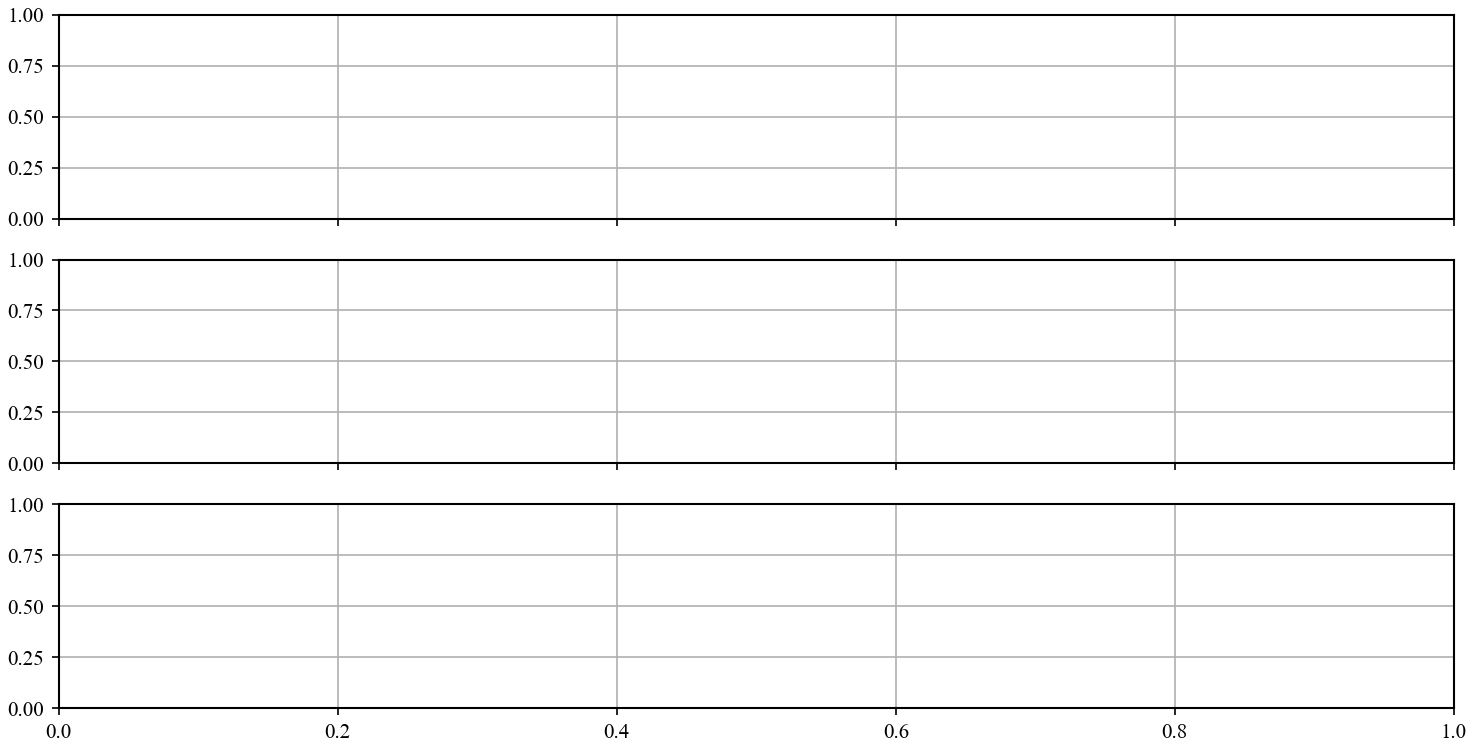

In [65]:
plot_series_v2(forecasts_df=res_df, level=levels, anomalies_df=anomalies)

In [64]:
def plot_series_v2(
    df: Optional[pd.DataFrame] = None,
    forecasts_df: Optional[pd.DataFrame] = None,
    anomalies_df: Optional[pd.DataFrame] = None,
    palette: Optional[str] = 'tab10',
    ids: Optional[List[str]] = None,
    plot_random: bool = True,
    max_ids: int = 8,
    models: Optional[List[str]] = None,
    level: Optional[List[float]] = None,
    max_insample_length: Optional[int] = None,
    plot_anomalies: bool = False,
    engine: str = "matplotlib",
    id_col: str = "unique_id",
    time_col: str = "ds",
    target_col: str = "y",
    seed: int = 0,
    resampler_kwargs: Optional[Dict] = None,
    ax: Optional[Union[plt.Axes, np.ndarray, "plotly.graph_objects.Figure"]] = None,
    figsize_per_plot: Tuple[float, float] = (12, 2),
    n_cols: int = 1,
    marker_size: int = 50,
):
    if engine != "matplotlib":
        return uf_plot_series(
            df=df, forecasts_df=forecasts_df, models=models, level=level,
            max_insample_length=max_insample_length, plot_anomalies=plot_anomalies,
            engine=engine, palette=palette, id_col=id_col, time_col=time_col,
            target_col=target_col, resampler_kwargs=resampler_kwargs, ax=ax
        )

    if df is None and forecasts_df is None:
        raise ValueError("At least one of `df` or `forecasts_df` must be provided.")

    # === Отбор ID ===
    all_ids = set()
    if df is not None: all_ids.update(df[id_col].unique())
    if forecasts_df is not None: all_ids.update(forecasts_df[id_col].unique())
    if anomalies_df is not None: all_ids.update(anomalies_df[id_col].unique())
    
    all_ids = sorted(all_ids)

    if not all_ids: raise ValueError("No series found in provided data.")

    if ids is None:
        if plot_random:
            np.random.seed(seed)
            selected_ids = list(np.random.choice(all_ids, size=min(max_ids, len(all_ids)), replace=False))
        else:
            selected_ids = all_ids[:max_ids]
    else:
        selected_ids = [uid for uid in ids if uid in all_ids][:max_ids]

    if not selected_ids: raise ValueError("No valid IDs to plot.")

    # Фильтрация основных данных
    df_filtered = df[df[id_col].isin(selected_ids)] if df is not None else None
    forecasts_filtered = forecasts_df[forecasts_df[id_col].isin(selected_ids)] if forecasts_df is not None else None

    n_plots = len(selected_ids)

    # Если передан внешний ax
    if ax is not None:
        return uf_plot_series(
            df=df_filtered, forecasts_df=forecasts_filtered, models=models, level=level,
            max_insample_length=max_insample_length, plot_anomalies=plot_anomalies,
            engine=engine, palette=palette, id_col=id_col, time_col=time_col,
            target_col=target_col, resampler_kwargs=resampler_kwargs, ax=ax
        )

    # === Расчёт сетки ===
    if n_cols == -1:
        n_cols, n_rows = n_plots, 1
    else:
        n_cols = min(n_cols, n_plots)
        n_rows = (n_plots + n_cols - 1) // n_cols

    # === Создаём фигуру ===
    width, height = figsize_per_plot
    fig, axes = plt.subplots(
        nrows=n_rows, ncols=n_cols,
        figsize=(width * n_cols, height * n_rows),
        sharex=True, squeeze=False
    )
    axes = axes.flatten()

    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)

    # === КЛЮЧЕВОЙ МОМЕНТ: Определяем порядок ID ===
    # uf_plot_series будет рисовать в том порядке, в котором unique_id встречаются в df (или forecasts).
    # Мы должны взять этот порядок ТОЧНО.
    plotting_order = []
    if df_filtered is not None:
        plotting_order = df_filtered[id_col].unique().tolist()
    elif forecasts_filtered is not None:
        plotting_order = forecasts_filtered[id_col].unique().tolist()
    
    # На всякий случай фильтруем, чтобы были только нужные ID (хотя фильтрация уже была)
    plotting_order = [uid for uid in plotting_order if uid in selected_ids]

    # === Рисуем аномалии ===
    if anomalies_df is not None:
        anom_filtered = anomalies_df[anomalies_df[id_col].isin(plotting_order)].copy()
        
        for i, uid in enumerate(plotting_order):
            # Берем точки только для текущего ID
            points = anom_filtered[anomalies_filtered[id_col] == uid]
            
            if not points.empty:
                axes[i].scatter(
                    points[time_col],
                    points[target_col],
                    color='red',
                    s=marker_size,
                    marker='o',
                    edgecolors='black',
                    linewidths=1,
                    label='Anomaly',
                    zorder=100
                )

    # Вызываем оригинальную функцию
    return uf_plot_series(
        df=df_filtered,
        forecasts_df=forecasts_filtered,
        models=models,
        level=level,
        max_insample_length=max_insample_length,
        plot_anomalies=plot_anomalies,
        engine=engine,
        palette=palette,
        id_col=id_col,
        time_col=time_col,
        target_col=target_col,
        resampler_kwargs=resampler_kwargs,
        ax=axes[:n_plots],
    )

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression

# Nixtla
from statsforecast import StatsForecast
from statsforecast.models import MSTL, SimpleExponentialSmoothingOptimized
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from utilsforecast.plotting import plot_series # или ваша функция plot_series_v2

# Aeon (для третьего метода)
# pip install aeon
from aeon.anomaly_detection import DWT_ML 

# --- 0. Подготовка данных (как у вас, но с добавлением аномалий) ---
# Предполагаем, что panel_df уже создан вашим кодом выше.
# Давайте искусственно добавим аномалии в обучающую выборку, чтобы их найти.

df_train_anom = df_train.copy()
# Добавим резкие выбросы в 'Consumption' для примера
anom_indices = df_train_anom[(df_train_anom['unique_id'] == 'Consumption') & 
                             (df_train_anom['ds'].isin(['2020-01-05', '2020-03-15']))].index

# Делаем "провал" и "всплеск"
df_train_anom.loc[anom_indices[0], 'y'] = df_train_anom.loc[anom_indices[0], 'y'] * 0.5 # Странное падение
df_train_anom.loc[anom_indices[1], 'y'] = df_train_anom.loc[anom_indices[1], 'y'] * 2.0 # Странный пик

print(f"Всего аномалий внесено: {len(anom_indices)}")

# --- МЕТОД 1: Через прогноз и остатки (StatsForecast) ---
print("--- Method 1: Residuals & Intervals ---")

# Используем вашу модель MSTL
models_sf = [MSTL(season_length=[SEASON], alias='MSTL_MODEL')]
sf = StatsForecast(models=models_sf, freq=FREQ)

# 1. Делаем In-Sample прогноз (прогноз на историю), чтобы найти аномалии в прошлом
# или прогнозируем на тест и сравниваем с тестом.
# Для детекции аномалий в истории используем forecast_fitted_values (доступно в новых версиях)
# или просто обучаем и предсказываем.

sf.fit(df_train_anom)
# Получаем прогноз на том же горизонте (in-sample prediction)
# В StatsForecast для получения in-sample прогнозов удобнее использовать fitted=True при forecast 
# или просто получить остатки. 
# Но так как нам нужно сравнить с реальностью, сделаем через predict на тесте, если ищем аномалии в будущем.
# Если ищем в прошлом - используем predict_in_sample (в новых версиях).

# Давайте сделаем проще: предскажем будущее и найдем аномалии в тесте (df_test)
# Или сделаем Cross Validation на трейне.

# Вариант "Cross Validation" для поиска аномалий на трейне:
crossval_df = sf.cross_validation(
    df=df_train_anom,
    h=1, # шаг вперед
    n_windows=len(df_train_anom)//SEASON, # несколько окон
).reset_index()

# Считаем остатки
crossval_df['residual'] = crossval_df['y'] - crossval_df['MSTL_MODEL']

# Простое правило: если остаток > 3 стандартных отклонений -> Аномалия
# (или используем квантили)
std_resid = crossval_df['residual'].std()
crossval_df['anomaly_sf'] = np.where(np.abs(crossval_df['residual']) > 2.5 * std_resid, 1, 0)

print(f"Найдено аномалий через остатки: {crossval_df['anomaly_sf'].sum()}")

# Визуализация (пример для Consumption)
df_plot = df_train_anom[df_train_anom['unique_id'] == 'Consumption'].copy()
anom_points = crossval_df[(crossval_df['unique_id'] == 'Consumption') & (crossval_df['anomaly_sf']==1)]

plt.figure(figsize=(12, 4))
plt.plot(df_plot['ds'], df_plot['y'], label='y')
plt.scatter(anom_points['ds'], anom_points['y'], color='red', label='Anomaly', zorder=5)
plt.title("Method 1: Anomaly Detection via MSTL Residuals")
plt.legend()
plt.show()


# --- МЕТОД 2: Sklearn Adapter (MLForecast + IsolationForest) ---
print("--- Method 2: Sklearn Adapter (Isolation Forest) ---")

# IsolationForest обучается без учителя (y не нужен при predict, только fit)
# В MLForecast fit требует y для генерации лагов.
# Мы обманем систему: обучим на "нормальных" данных (если бы они были) или на всех.
# IsolationForest в sklearn имеет методы fit и predict(sample).
# Но sklearn.predict возвращает 1 (норма) или -1 (аномалия).
# Nixtla ожидает, что predict вернет значение ряда. 
# Поэтому мы напишем простую обертку, чтобы она возвращала флаг аномалии как "прогноз".

class AnomalyWrapper:
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y=None):
        # X - матрица признаков (лаги), сгенерированная MLForecast
        # Isolation Forest не требует y, ему нужен только X
        self.model.fit(X)
        return self
    
    def predict(self, X):
        # Возвращаем -1 как 1 (аномалия), 1 как 0 (норма)
        preds = self.model.predict(X)
        return np.where(preds == -1, 1, 0) # 1 - аномалия, 0 - норма

# Создаем пайплайн MLForecast
fcst_anom = MLForecast(
    models={'IForest': AnomalyWrapper(IsolationForest(contamination=0.05, random_state=42))},
    freq=FREQ,
    lags=[1, 2, 3, 4, 52], # Используем прошлые значения как признаки
    # target_transforms=[] # Лучше без трансформаций для IF, или стандартизировать внутри
)

# Обучаем (Это In-Sample детекция)
# fit генерирует X из лагов и вызывает AnomalyWrapper.fit
fcst_anom.fit(df_train_anom)

# predict в MLForecast делает forecast вперед. 
# Для In-Sample предсказания используем метод predict_in_sample или cross_validation в MLForecast
# В новых версиях MLForecast есть predict_in_sample или мы используем preprocess + model.predict

# Получаем признаки (X), которые сгенерировал MLForecast
X, y = fcst_anom.preprocess(df_train_anom, return_X_y=True)

# Применяем нашу модель напрямую к этим данным
anomaly_preds = fcst_anom.models_['IForest'].predict(X.values)

# Сохраняем результат
res_df = df_train_anom.iloc[-len(anomaly_preds):].copy() # берем только часть, где есть лаги
res_df['anomaly_if'] = anomaly_preds

print(f"Найдено аномалий через IForest: {res_df['anomaly_if'].sum()}")

# Визуализация
anom_if = res_df[(res_df['unique_id'] == 'Consumption') & (res_df['anomaly_if']==1)]
plt.figure(figsize=(12, 4))
plt.plot(df_plot['ds'], df_plot['y'], label='y', alpha=0.5)
plt.scatter(anom_if['ds'], anom_if['y'], color='orange', label='IForest Anomaly', zorder=5, marker='x')
plt.title("Method 2: Sklearn Adapter (IsolationForest) inside Nixtla")
plt.legend()
plt.show()


# --- МЕТОД 3: Интеграция aeon (Custom Model) ---
print("--- Method 3: Aeon Integration ---")

# aeon требует 2D numpy array (n_samples, n_features). Для унивариантного ряда это (n, 1).
# Напишем адаптер, который Nixtla будет дергать.

class AeonWrapper:
    def __init__(self, aeon_model):
        self.aeon_model = aeon_model
    
    def fit(self, X, y=None):
        # X здесь - DataFrame от MLForecast (лаги), нам нужен исходный ряд.
        # В MLForecast мы не можем легко достать исходный y внутри fit, если он трансформирован.
        # ПОЭТОМУ для aeon лучше использовать отдельный вызов, 
        # ИЛИ использовать архитектуру, где мы передаем данные в модель при инициализации 
        # (но это ломает паттерн Nixtla).
        
        # ЛУЧШИЙ ПОДХОД для aeon внутри лабы: 
        # Не пихать его насильно в MLForecast.fit/predict цикл, 
        # а использовать Nixtla только для подготовки данных в нужный формат.
        pass 
        return self

# Так как aeon.anomaly_detection работает со всем рядом целиком, а Nixtla по группам/уникальным id,
# лучше реализовать отдельную функцию-адаптер, которая работает с `panel_df`.

def detect_anomalies_aeon(panel_df, model_aeon):
    results = []
    for uid, df_grp in panel_df.groupby('unique_id'):
        # aeon принимает (n_timepoints,) или (n_timepoints, n_channels)
        series = df_grp['y'].values
        
        # Обучаем и предсказываем (fit_predict для детекции)
        # aeon модели обычно имеют fit_predict
        scores = model_aeon.fit_predict(series)
        
        # scores - это оценки аномальности (чем выше, тем более аномально)
        # Обычно порог ставят или используют percentile
        threshold = np.percentile(scores, 95) # Топ 5% аномальных
        
        df_res = df_grp.copy()
        df_res['anomaly_score'] = scores
        df_res['anomaly_aeon'] = (scores > threshold).astype(int)
        results.append(df_res)
        
    return pd.concat(results)

# Используем метод из aeon, например DWT_ML (Decision Tree на вейвлетах) или PYOD
aeon_model = DWT_ML() # или aeon.anomaly_detection.PyOD(IsolationForest(...))

aeon_results = detect_anomalies_aeon(df_train_anom, aeon_model)

# Визуализация
anom_aeon = aeon_results[(aeon_results['unique_id'] == 'Consumption') & (aeon_results['anomaly_aeon']==1)]
plt.figure(figsize=(12, 4))
plt.plot(df_plot['ds'], df_plot['y'], label='y', alpha=0.5)
plt.scatter(anom_aeon['ds'], anom_aeon['y'], color='purple', label='Aeon Anomaly', zorder=5, marker='s')
plt.title("Method 3: Aeon Toolkit Integration")
plt.legend()
plt.show()